Tareq El Kajjyouy

> Nature uses only the longest threads to weave her patterns, so that each small piece of her fabric reveals the organization of the entire tapestry. - Richard P. Feynman

#**DAMAGE PROPAGATION IN A U-BOLT (FKPP)**
## Reason for which I chose this project work
I decided to analyze the *damage propagation in a U-bolt*. I chose this project work since I found it extremely compliant with my academic path and since I had the desire to apply my knowledge to a time-dependent problem.



## Model Order Reduction for the FKPP Equation
The fatigue behavior of the system is described by the KPP-Fischer equation, which is:
$$
\begin{cases}
\frac{\partial u}{\partial t} - D\Delta u = ru(1 - u) & \text{in } \Omega \times (0,T] \\
\nabla u \cdot \mathbf{n} = 0 & \text{on } \partial\Omega \times (0,T] \\
u(\cdot, 0) = g_\delta & \text{in } \overline{\Omega},
\end{cases}
$$

on which the value of $u$ is expected to vary between $0$ and $1$. This value, obviously, is *adimensional* as it has been normalized. The partial differential equation is quasi-linear and parabolic as it is easily possible to demonstrate.

I am expected to perform a reduced order modelling by choosing one between:
### **1. POD-NN**: Based on developing a POD basis and then training a NN.
### **2. DL-ROM**: Based on developing an autoencoder.

### **Reasoning behind the choice:**
How can I choose which model order modelling is more convenient? One technique, as discussed in class, can be to perform the POD and see which are the eventual number of singular values to be considered for our analysis. If the number of modes to be considered is expected to be quite high, then it would be more convenient and safe to apply DL-ROM, instead of POD-NN. But why? The reason behind this choice is that having a large amount of modes might significantly increases the complexity and computations of our system, especially, as we will see in point 4, for the application of SINDy. Therefore, it would be better to rely on a different approach which allows to have less representative modes of the system. The *nonlinear* behavior of DL-ROM allows to compress the same information in a very low number of modes. Linearity does not give us this significant advantage.

### **Which one did I use for step 1 between POD-NN and DL-ROM?**
For completeness, I decided to apply both of them in order to discuss and to show the results I obtained. However, as it is possible to see, DL-ROM is expected, as expected, to be more compliant for the analysis.

### **Important note:**
Along the entire file, it is possible to see that the shape of many variable are shown. This is done in order to assure that the analysis was correctly done and to show to the reader that the obtained result fits what was expected to obtain. This was an advice given by the lecturer from that I followed. In addition, many times I pass to tensors, gpu and cpu. These changes have been done exclusively to avoid any coding error. The development of the neural network is explained near the cells where there is the training.

### **Full analysis of the POD:**

1. I splitted the data as requested from the lecturer, defined the given values (such as $dt = 0.0005$, $T = 0.02$, $nt = 41$ and $p = 3$) and associated these values with the solution u.

2. I defined u in terms of a 2D matrix. This was helpful in order to define the trajectory along time of only the first $75$ samples, i.e. the training ones. Consequently, I applied the SVD to such matrix in order to determine the *left eigenvectors'* matrix. As a result, I plotted the spectrum of the singular values from which I determined the number of modes that I want to consider, i.e. $50$.

3. I analyzed the $L^2$ deriving from the POD. To do it, I defined, obviously, u_proj, that is the FOM representation of the solution obtained through POD.

### **Full analysis of POD-NN:**

1. I simply defined the neural network to be trained on the offline stage, i.e. $\Pi(\mu) ≈ V^T u_h (\mu)$ (I called it $c$). I developed the matrix of $\mu$, that is a matrix which considers also time as a parameter. With POD-NN, we had two different approaches to consider time. I decided to consider time as a parameter as we did during the labs.

2. I train the neural network, developing some activation functions and performing multiple epochs. As a result, I obtain the reduced representation.

3. I determine the reduced solution on the latent space => We do **not** apply Galerkin projection. We apply the neural network.

4. I determine the the $L^2$ error that we expect with the POD-NN with respect to $u$.

### **Full analysis of DL-ROMS:**

1. I defined the same $\mu$ matrix that I defined with POD-NN. ALso here I considered time as a parameter.

2. I trained the encoder $\phi$ and the decoder $\Psi$.

3. I applied the encoder in order to determine the solution in the latent space. The encoder allows to reach the latent space, while the decoder allows to go back to the FOM space. As we will see, to reach the latent space, it is possible to apply also a different approach (by using $\Phi$). In this case, just for sake of completeness, I defined the solution in the latent space for all the dataset, for the training part only and for the testing part only.

4. Finally, as done multiple times with POD-NN, I determined the $L^2$ error between the latent solution of the tests with the tests of the FOM solution.  

### **Results:**

POD-NN and DL-ROM both satisfy the requirement of the $L^2$ error, therefore, under this specific point of view, we are satisfied pretty much with both. However, even if the error is satisfied, DL-ROM shows a much more smaller space wrt POD-NN. In addition, the number of modes of POD-NN is extremely high. This will give us some problems for the 4th point.

In [ ]:
try:
    import gdown
except ImportError:
    !pip install gdown
    import gdown


file_ids = {
    'POD_NN_model.pth': '11-E6AyUAIh-UNv-bgbuJDKdchZHJTRwk',
    'DLROM_autoencoder.pth': '121eFOgcpTCPb0oCq9vO6TThfzWrm-mWM',
    'DLROM_phi_mapper.pth': '1qb8uxm7CfjfAG0r_00yJwQYgiTE4_I48',
}

# Download each file
for file_name, file_id in file_ids.items():
    if 'YOUR_' in file_id: # Check if the ID is still a placeholder
        print(f"Skipping download for '{file_name}' as the file ID is a placeholder. Please update it in the `file_ids` dictionary.")
        continue

    output_path = f'/content/{file_name}'
    try:
        gdown.download(id=file_id, output=output_path, quiet=False)
        print(f"Downloaded '{file_name}' to '{output_path}'.")
    except Exception as e:
        print(f"Error downloading '{file_name}' with ID '{file_id}': {e}")
        print(f"Please ensure the file ID is correct and the file is publicly accessible or 'Anyone with the link' can view it.")

print("Finished attempting to download all specified files.")


Downloading...
From: https://drive.google.com/uc?id=11-E6AyUAIh-UNv-bgbuJDKdchZHJTRwk
To: /content/POD_NN_model.pth
100%|██████████| 164k/164k [00:00<00:00, 62.3MB/s]


Downloaded 'POD_NN_model.pth' to '/content/POD_NN_model.pth'.


Downloading...
From (original): https://drive.google.com/uc?id=121eFOgcpTCPb0oCq9vO6TThfzWrm-mWM
From (redirected): https://drive.google.com/uc?id=121eFOgcpTCPb0oCq9vO6TThfzWrm-mWM&confirm=t&uuid=bda0762e-a878-4bd0-ab0b-ef3b30a9b72f
To: /content/DLROM_autoencoder.pth
100%|██████████| 44.1M/44.1M [00:00<00:00, 169MB/s]


Downloaded 'DLROM_autoencoder.pth' to '/content/DLROM_autoencoder.pth'.


Downloading...
From: https://drive.google.com/uc?id=1qb8uxm7CfjfAG0r_00yJwQYgiTE4_I48
To: /content/DLROM_phi_mapper.pth
100%|██████████| 141k/141k [00:00<00:00, 53.6MB/s]

Downloaded 'DLROM_phi_mapper.pth' to '/content/DLROM_phi_mapper.pth'.
Finished attempting to download all specified files.


In [ ]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*
import numpy as np
import matplotlib.pyplot as plt
import gdown
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import time
from IPython.display import clear_output as clc
import torch
from torch import tanh
from torch.optim import Adam
import os # Added for file existence checks
clc()

In [ ]:
import numpy as np
import torch

# You can use the full sharing URL, and the code will attempt to extract the ID.
GOOGLE_DRIVE_LINK_OR_ID = 'https://drive.google.com/file/d/1WHtfJjr9IgqcX58T4jYy3s7tD2es-9kx/view?usp=sharing'

# Extract just the ID if a full link is provided
if 'drive.google.com/file/d/' in GOOGLE_DRIVE_LINK_OR_ID:
    GOOGLE_DRIVE_FILE_ID = GOOGLE_DRIVE_LINK_OR_ID.split('/d/')[1].split('/view')[0]
else:
    GOOGLE_DRIVE_FILE_ID = GOOGLE_DRIVE_LINK_OR_ID

# --- Load Numerical Data ---
# This assumes the files have been copied to /content/ by the previous cell.

print("Finished loading all available numerical data.")

Finished loading all available numerical data.


### Mesh construction

In [ ]:
# We define the x and y points through a vector.
points = [np.array([0.0, 0.0])]

# Trace a line; used to define the vectorial displacement (complex numbers)
def step(z):
  points.append(points[-1] + [z.real, z.imag])

# This allows to develop the arch of the U-bolt
def arch(r, thetas, knots = 30):
  rho = np.abs(r)
  center = points[-1] + [r.real, r.imag]
  th = np.linspace(*thetas, knots)[1:]
  shift = rho*np.exp(1j*th)
  vals = np.stack([center[0] + shift.real, center[1]+shift.imag], axis = 1)
  for v in vals:
    points.append(v)

# This part realizes the sequential 2D closed geometric profile, by defining the vertices.
step(3j)
arch(2, thetas = (np.pi, 0))
step(-3j)
step(-1)
step(3j)
arch(-1, thetas = (0, np.pi))
step(-3j)
step(-1)

# Define an array of shape (N, 2)
points = np.stack(points)

# Define the domain and the mesh (as we did in LAB 2)
domain = fe.polygon(points)                                 # we define the domain. The domain is defined through the step and arch functions.
mesh = fe.mesh(domain, stepsize = 0.05)                     # The step size is very low
Vh = fe.space(mesh, 'CG', 1)                                # Continuous Galerking is given by "CG" and degree of polynomial = 1
clc()

points.shape

(65, 2)

In [ ]:
print(f"The number of the degrees of freedom of the FOM is {Vh.dim()}")

The number of the degrees of freedom of the FOM is 6636


## Data download

In [ ]:
# Data download
gdown.download(id = "1ehojde4rL-8-zoyiKikes3e76CpPvJzC", quiet = False, output = "u-bolt.npz")
clc()

data = np.load("u-bolt.npz")
mu, u = dv.tensor(data['mu'], data['u'])

# Define the shape of mu and u
mu.shape, u.shape

(torch.Size([100, 3]), torch.Size([100, 41, 6636]))

In [ ]:
print(f"The mu vector has shape {mu.shape}, where '100' is associated to the number of the dataset, while 3 is associated to the number of parameters")

The mu vector has shape torch.Size([100, 3]), where '100' is associated to the number of the dataset, while 3 is associated to the number of parameters


In [ ]:
print(f"u is a tensor has shape {u.shape}, where N = '100', nt = '41' and nh = '6636'")

u is a tensor has shape torch.Size([100, 41, 6636]), where N = '100', nt = '41' and nh = '6636'


## Color for the damage

In [ ]:
# Damage plot with modified colors
from matplotlib.colors import ListedColormap
import matplotlib as mpl
jet = mpl.colormaps['jet']
jet_colors = jet(np.linspace(0, 1, 256))
def modify_jet_to_gray(jet_colors):
    new_colors = jet_colors.copy()
    gray_vals = np.linspace(0.3, 0.7, 85)
    for i in range(85):
        new_colors[i, 0:3] = gray_vals[i]
    return ListedColormap(new_colors)
gray_jet = modify_jet_to_gray(jet_colors)

In [ ]:
import os
import numpy as np
import gdown

FILE_NAME = 'Assignment2_Tareq_Data_Full.npz'
GOOGLE_DRIVE_LINK = 'https://drive.google.com/file/d/1ECKU1wre7MFrdf7Fsfk-w9G-HYe-3__M/view?usp=sharing'

def to_np(var):
    return var.detach().cpu().numpy() if hasattr(var, 'detach') else var

if 'drive.google.com/file/d/' in GOOGLE_DRIVE_LINK:
    GOOGLE_DRIVE_FILE_ID = GOOGLE_DRIVE_LINK.split('/d/')[1].split('/view')[0]
else:
    GOOGLE_DRIVE_FILE_ID = GOOGLE_DRIVE_LINK

if os.path.exists(FILE_NAME):
    print(f"Loading data from existing '{FILE_NAME}' file...")
    data = np.load(FILE_NAME)
    mu, time_grid, points = data['mu'], data['time_grid'], data['mesh_points']
    Vn, uROM = data['Vn'], data['uROM']
    mu_opt, mu_opt_dlrom = data['mu_opt'], data['mu_opt_dlrom']
    upred_sindy_dlrom = data['upred_sindy_dlrom']
    damage_at_x_star_sindy = data['damage_at_x_star_sindy']
    damage_at_x0 = data['damage_at_x0']
    damage_measurements = data['damage_measurements']
    print("Data loaded successfully!")

elif GOOGLE_DRIVE_FILE_ID:
    print(f"Downloading '{FILE_NAME}' from Google Drive...")
    try:
        gdown.download(id=GOOGLE_DRIVE_FILE_ID, output=FILE_NAME, quiet=False)
        data = np.load(FILE_NAME)
        print("Data downloaded and loaded successfully!")
    except Exception as e:
        print(f"Error: {e}")

Loading data from existing 'Assignment2_Tareq_Data_Full.npz' file...
Data loaded successfully!


## Splitting the data

In [ ]:
# Define N (dataset number), nt (time snapshots) and nh (number of dofs), dt and T (period)
N, nt, nh = u.shape
dt = 5e-4
T = (nt-1) * dt

# Split the data (considering that N = 100)
ntrain = int(0.75*N)
ntrain_total = ntrain * nt
ntest = int(0.25*N)
ntest_total = ntest * nt
p = mu.shape[1]

ntrain, ntest

(75, 25)

In [ ]:
T, nt, u.shape, mu.shape                                                        # mu = 100 means that we have 100 trajectories

(0.02, 41, torch.Size([100, 41, 6636]), (100, 3))

In [ ]:
# We must pass to tensors
mu, u = dv.tensor(mu, u)

/usr/local/lib/python3.12/dist-packages/dlroms/cores.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (*[ttensor(array, dtype = self.dtype, device = self.device) for array in arrays],)


## POD evaluation

To understand if we must deal with POD-NN or with DL-ROM, let us see the svd decay behavior

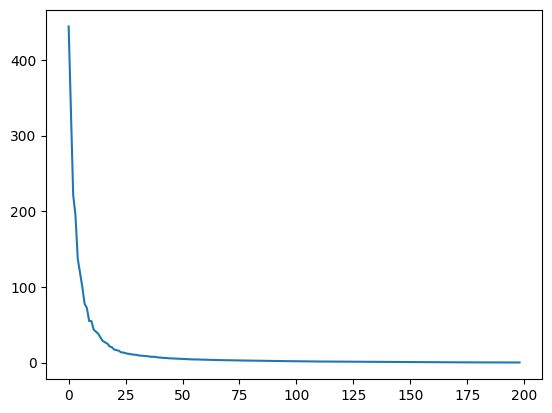

In [ ]:
# Introduce the library needed to calculate the SVD
from scipy.linalg import svd

# Define the object that must be trained
Utrain = (u[:ntrain]).reshape(ntrain*nt, nh).T                                  # I want a matrix; I truncate u until ntrain before it becomes a matrix. Otherwise, I had to use ntrain_total.

# To pass to cpu
Utrain_np = Utrain.detach().cpu().numpy()
# Calculate the SVD on the training data
X, s, _ = svd(Utrain_np, full_matrices = False)                                 # I don't define Yt since I do not need it during the analysis of this problem

# Plot
plt.plot(s[1:200])

In [ ]:
Utrain.shape

torch.Size([6636, 3075])

Number of the basis functions to be considered

In [ ]:
n = 50                                                                      # number of basis functions to be considered (I decided it from the graph's behavior; I considered an even number for purpose). The idea is to see the index for which  the curve starts being around zero.
Vn = X[:, :n]                                                               # Truncate the left eigenvectors' matrix up to n
print(f"The shape of Vn is expected to be {Vn.shape}, which shows how the dimension is like {X.shape} in terms of columns, but in terms of rows we truncate many eigenvectors because they have a low energy.")


The shape of Vn is expected to be (6636, 50), which shows how the dimension is like (6636, 3075) in terms of columns, but in terms of rows we truncate many eigenvectors because they have a low energy.


In [ ]:
# It is needed for the error (later)
l2 = L2(Vh) #we create the norm  and it expects input like ... x Nh
l2.cuda()
clc()

## Analyze the error coming from the POD

In [ ]:
# Pass to tensors
mu, u, Vn = dv.tensor(mu, u, Vn)

# Define the projected form of the solution "u" (i.e. the reduced form of u)
uproj = u @ Vn @ Vn.T                                                           # We could also write u uproj = Vn @ Vn.T @ u

u.shape, uproj.shape                                                            # They are the same because they both represent u_h

/usr/local/lib/python3.12/dist-packages/dlroms/cores.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (*[ttensor(array, dtype = self.dtype, device = self.device) for array in arrays],)


(torch.Size([100, 41, 6636]), torch.Size([100, 41, 6636]))

In [ ]:
# Calculate the formula of the error
relative_error = (torch.linalg.norm(u - uproj, dim=2)/ torch.linalg.norm(u, dim=2))
avg_relative_error = relative_error.mean()

# Print the error value
print("Average relative L2 error: %.4f%%" % (100 * avg_relative_error))

Average relative L2 error: 1.8781%


In [ ]:
print("The average L2 error is very low! Let us now introduce the neural network.")

The average L2 error is very low! Let us now introduce the neural network.


## 1) POD-NN

### 1. Define the neural network and the matrix of $\mu$

In [ ]:
Vn = Vn.cuda()
Vn.shape

torch.Size([6636, 50])

In [ ]:
# Reshape u
u2 = u.reshape(nt*N, nh)
uproj2 = uproj.reshape(nt*N, nh)

# Define c (it is needed when we deal with the POD) => c is simply the neural network of the offline phase
c = u2 @ Vn
c = dv.tensor(c)

# Define the number of parameters (i.e. the number of columns on the matrix "mu"; note that the number of rows correspond to the number of dataset); p is a scalar
p = mu.shape[1]
c.shape # 4100 = nt * ndata, n

# Print the shapes
print(f"The shape of c is {c.shape[0]} = ntime * dataset, while  {c.shape[1]} = n")

The shape of c is 4100 = ntime * dataset, while  50 = n


/usr/local/lib/python3.12/dist-packages/dlroms/cores.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return ttensor(arrays[0], dtype = self.dtype, device = self.device)


In [ ]:
# I create the size which fits the number of parameters of our system (time included)
mut = torch.zeros(N, nt, p + 1)
times = torch.linspace(0, T, nt)

# I add elements inside the tensor of my interest for each sample (i.e. N = 100)
for i in range(N):
    mut[i, :, :p] = mu[i]
    mut[i, :, p] = times

mut = mut.reshape(-1, p+1)
mut = dv.tensor(mut)
print(f"The shape of mu is {mut.shape[0]} = ntime * dataset, while  {mut.shape[1]} = number of parameters")
mut.shape

The shape of mu is 4100 = ntime * dataset, while  4 = number of parameters


torch.Size([4100, 4])

### 2. OFFLINE TRAINING: Train the data (pass from $\mathbb{R}^p \to \mathbb{R}^n$; $\phi(\mu_i) \approx c_i$) + ROM

In [ ]:
u2 = u2.cpu()
mut = mut.cpu()
Vn = Vn.cpu()
c = c.cpu()

In [ ]:
phi = Dense(p+1, 128, gelu) + Dense(128, 128, gelu) + Dense(128, 128, gelu) + Dense(128, n, activation = None)
model = DFNN(phi)
model.He()
# model.train(mut, c, ntrain = ntrain_total, epochs = 100, loss = mse(euclidean))  # mut is the input, while the output c

# Load state dictionary if available, otherwise train
if os.path.exists('/content/POD_NN_model.pth'):
    print("Loading pre-trained 'model' state dictionary.")
    model.load_state_dict(torch.load('/content/POD_NN_model.pth'))
    model.eval() # Set to evaluation mode
else:
    print("No pre-trained 'POD_NN_model.pth' found. Training model...")
    # Train the neural network
    model.train(mut, c, ntrain = ntrain, epochs = 100, loss = mse(euclidean))

# This complex problem requires a wider network;
# SHRED-ROM uses hidden layers with 350–400 neurons to map sensor data or parameters to reduced-order coefficients.
# Choosing 128 neurons significantly increases the model’s capacity to capture structural damage complexity while remaining efficient enough to train on a standard laptop.

Loading pre-trained 'model' state dictionary.


In [ ]:
phi.freeze()
model(mut[ntrain_total:]).shape , Vn.T.shape

(torch.Size([1025, 50]), torch.Size([50, 6636]))

### 3. Define the reduced solution

In [ ]:
# Define the reduced solution by applying the neural network. Here, we AVOID applying the Galerkin projection
uROM = model(mut[ntrain_total:]) @ Vn.T

In [ ]:
uROM.shape, u.shape

(torch.Size([1025, 6636]), torch.Size([100, 41, 6636]))

In [ ]:
print(f"The shape of uROM is {uROM.shape}, where the {uROM.shape[0]} = ntest * ntrain (i.e. {ntest} * {ntrain}), while {uROM.shape[1]} = number of degrees of freedom.")
print("The solution uROM is EXCLUSIVELY applied on the test set. The training set has been exclusively used for the training of the layers.")

The shape of uROM is torch.Size([1025, 6636]), where the 1025 = ntest * ntrain (i.e. 25 * 75), while 6636 = number of degrees of freedom.
The solution uROM is EXCLUSIVELY applied on the test set. The training set has been exclusively used for the training of the layers.


In [ ]:
mut.shape, mut[ntrain_total:].shape, uROM.shape, u2[ntrain_total:].shape

(torch.Size([4100, 4]),
 torch.Size([1025, 4]),
 torch.Size([1025, 6636]),
 torch.Size([1025, 6636]))

### 4. Error analysis of POD-NN

In [ ]:
# Define the function of the error
def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, nt).sum(axis = -1)/l2(utrue).reshape(-1, nt).sum(axis = -1)).mean()

In [ ]:
l2 = L2(Vh) # We create the norm  and it expects input like ... x Nh
l2.cuda()
clc()

In [ ]:
uROM = dv.tensor(uROM)
u2 = dv.tensor(u2)

In [ ]:
print("The L squared error of the POD-NN is: %s" % num2p(error(u2[ntrain_total:], uROM)))

The L squared error of the POD-NN is: 5.65%


## 2) DL-ROM

### 1. Define the $\mu$ matrix

In [ ]:
print("Trajectories:\t%d." % N)
print("Timesteps:\t%d." % nt)
print("FOM dimension:\t%d." % nh)
print("Parameters:\t%d." % p)

Trajectories:	100.
Timesteps:	41.
FOM dimension:	6636.
Parameters:	3.


In [ ]:
# I create the size which fits the number of parameters of our system (time included)
mut_dlrom = torch.zeros(N, nt, p + 1)
times_dlrom = torch.linspace(0, T, nt)

# I add elements inside the tensor of my interest for each sample (i.e. N = 100)
for i in range(N):
    mut_dlrom[i, :, :p] = mu[i]
    mut_dlrom[i, :, p] = times

mut_dlrom = mut_dlrom.reshape(-1, p+1)
mut_dlrom = dv.tensor(mut_dlrom)

mut_dlrom.shape
print(f"The number of columns of mut_dlrom is {mut_dlrom.shape[0]}, i.e. nt = 41 * N = 100")

The number of columns of mut_dlrom is 4100, i.e. nt = 41 * N = 100


### 2. Start the training of the encoder $\phi$ and of the decoder $\Psi$.

To apply the DL-ROMs, we do not need to do the POD. We only need to develop the offline training directly after the definition of our $\mu$ => $\mu$ is needed in order to calculate $u_{DLROM}$

In [ ]:
# Import the libraries
from torch.optim import Adam
import torch

# Define the activation functions; they are the best functions.
rho_encoder = lambda x: relu(x) - 10*relu(-x)    # Leaky ReLU for encoder
rho_decoder = lambda x: relu(x) - 0.1*relu(-x)     # Stronger Leaky ReLU for decoder
rho_sigmoid = lambda x: torch.sigmoid(x)

# Define the latent space (n can be between p and 2 * pi + 1 )
latent = 4

# Define the encoder and the decoder
encoder = Dense(nh, 600, rho_encoder) + Dense(600, latent, rho_encoder)
decoder = Dense(latent, 400, rho_decoder) + Dense(400, 1000, rho_decoder) + Dense(1000, nh, activation = None)

autoencoder = DFNN(encoder + decoder)

# Reshape and pass to GPU
u_flat = u.reshape(-1, nh)
autoencoder.cuda()
u_flat = u_flat.cuda()
mut = mut.cuda()
u = u.cuda()
l2.cuda()

# Check if the model is already saved, if so, load it
autoencoder_path = "DLROM_autoencoder.pth"
print(f"Loading pre-trained DL-ROM autoencoder from {autoencoder_path}")
autoencoder.load_state_dict(torch.load(autoencoder_path))

# Freeze the result obtained
autoencoder.freeze()

Loading pre-trained DL-ROM autoencoder from DLROM_autoencoder.pth


### 3. Define u of the DL-ROM

Consider both training and test data

In [ ]:
# Considering both training and test data
uLatent_total = encoder(u_flat)
ulatent_total_reshaped = uLatent_total.reshape(N, nt, latent).cuda()
uLatent_total.shape

torch.Size([4100, 4])

Consider only test data

In [ ]:
# Consider only test data
uLatent_test = encoder(u_flat[ntrain_total:])
ulatent_test_reshaped = uLatent_test.reshape(ntest, nt, latent).cuda()

uLatent_test.shape, ulatent_test_reshaped.shape

print(f"The difference in shape is that one has 3 values representing the shape, while the other is not. Indeed, the first one has {uLatent_test.shape}, while the reshaped has {ulatent_test_reshaped.shape}.")

The difference in shape is that one has 3 values representing the shape, while the other is not. Indeed, the first one has torch.Size([1025, 4]), while the reshaped has torch.Size([25, 41, 4]).


Consider only training data

In [ ]:
# Consider only test data
uLatent_train = encoder(u_flat[:ntrain_total])
uLatent_train_reshaped = uLatent_train.reshape(ntrain, nt, latent).cuda()

uLatent_train.shape, uLatent_train_reshaped.shape

(torch.Size([3075, 4]), torch.Size([75, 41, 4]))

Determine $\tilde{u}$$_h$ after the latent space

In [ ]:
# Determine u_h after the latent space
uh_final = decoder(uLatent_total)
uh_final_test = decoder(uLatent_test)
uh_final_train = decoder(uLatent_train)
uh_final_test_reshaped = uh_final_test.reshape(ntest, nt, nh)
uh_final_train_reshaped = uh_final_train.reshape(ntrain, nt, nh)

uh_final_test.shape, uh_final_train.shape, u_flat.shape

(torch.Size([1025, 6636]), torch.Size([3075, 6636]), torch.Size([4100, 6636]))

### 4. Define $\Phi$

In [ ]:
# Introduce a mu
mu_D_dl_rom = np.random.rand()
mu_r_dl_rom = np.random.rand()
mudelta_dl_rom = np.random.rand()
mu_eff_dl_rom = np.array([mu_D_dl_rom, mu_r_dl_rom, mudelta_dl_rom])

# Define mu with also time
mu_t_eff_dl_rom = torch.zeros(N, nt, p + 1)                                # 1 = number of trajectories; nt = number of time intervals; p = number of parameters
times = torch.linspace(0, T, nt)

# Consider the specific trajectory (i.e. one only)
for i in range(N):
    mu_t_eff_dl_rom[i, :, :p] = dv.tensor(mu_eff_dl_rom)
    mu_t_eff_dl_rom[i, :, p] = times
mu_t_eff_dl_rom = mu_t_eff_dl_rom.reshape(-1, p+1)                              # Do the reshape of mu_t_eff

# Passing to tensors
autoencoder.to(dv)
mu_t_eff_dl_rom = dv.tensor(mu_t_eff_dl_rom)
mu_eff_dl_rom = dv.tensor(mu_eff_dl_rom)

uh_final_test.shape, mu_t_eff_dl_rom.shape

(torch.Size([1025, 6636]), torch.Size([4100, 4]))

In [ ]:
# Import the library

phi_dlrom = DFNN(Dense(p + 1, 128, gelu) + Dense(128, 128, gelu) + Dense(128, 128, gelu) + Dense(128, latent, activation = None))
phi_dlrom.He()
phi_dlrom.cuda()

# Load state dictionary if available, otherwise train
if os.path.exists('/content/DLROM_phi_mapper.pth'):
     print("Loading pre-trained 'dlrom_phi' state dictionary.")
     phi_dlrom.load_state_dict(torch.load('/content/DLROM_phi_mapper.pth'))
     phi.eval() # Set to evaluation mode
else:
    print("No pre-trained 'DLROM_phi_mapper.pth' found. Training model...")
    phi_dlrom.train(mut_dlrom, uLatent_total, ntrain = ntrain_total, epochs = 100, loss = mse(euclidean))

phi.freeze()


Loading pre-trained 'dlrom_phi' state dictionary.


### 4. Determine the error

In [ ]:
print("The L squared error: %s" % num2p(error(u_flat[ntrain_total:], uh_final_test)))

The L squared error: 4.81%


In [ ]:
u2 = dv.tensor(u2)
dlrom = lambda mt: decoder(phi_dlrom(mt))                           # I will use it for the analysis of the efficiency
num2p(error(u2[ntrain_total:], dlrom(mut[ntrain_total:])))

/usr/local/lib/python3.12/dist-packages/dlroms/dnns.py:35: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  num2p = lambda prob : ("%.2f" % (100*prob)) + "%"


'6.92%'

## 1) EFFICIENCY WITH POD-NN

Now, I am expected to determine which is the efficiency of the reduced model(s) that we developed. In general, it was enough to define the efficiency for the DL-ROM, as the number of modes were significantly high in my opinion, bu for sake of completeness I did it for both.

### How does the algorithm work?
The implemented algorithm is the same for both. I decide to pick random values of the parameters (which, obviously, must belong between $[0,1]$) and apply the neural network to both (encoder for the DL-ROM and model for the POD-NN) in order to determine the reduced solution for both of them. Obviously, we must do the comparison between the reduced solution which is again in the $N_h$ dimension. Also here, I developed a matrix $\mu$ which follows the same identical criterion of the previous one.

### Results:
Both algorithms show a significant decrease of efficiency by using the same values of $\mu$.

In [ ]:
mut.shape, Vn.shape

(torch.Size([4100, 4]), torch.Size([6636, 50]))

In [ ]:
from time import perf_counter

# FOM analysis for one unique trajectory
dtFOM = 19.33      # time needed for the FOM

# Introduce a mu
mu_D = np.random.rand()
mu_r = np.random.rand()
mudelta = np.random.rand()
mu_eff = np.array([mu_D, mu_r, mudelta])

# Define mu with also time
mu_t_eff = torch.zeros(mu_eff.shape[0], nt, p + 1)                             # 1 = number of trajectories; nt = number of time intervals; p = number of parameters
times = torch.linspace(0, T, nt)

# Consider the specific trajectory (i.e. one only)
for i in range(3):
    mu_t_eff[i, :, :p] = mu_eff[i]
    mu_t_eff[i, :, p] = times
mu_t_eff = mu_t_eff.reshape(-1, p+1)                                           # Do the reshape of mu_t_eff

# Passing to tensors
model.to(dv)
phi.to(dv)
mu_t_eff = dv.tensor(mu_t_eff)
mu_eff = dv.tensor(mu_eff)
Vn = dv.tensor(Vn)

# ROM analysis
t0 = perf_counter()
model(mu_t_eff) @ Vn.T                                                         # ROM solution wrt the developed mu
t1 = perf_counter()
dtROM = t1-t0

# Printing
print("FOM solver:\t1 call = %.2f ms" % (1000*dtFOM))
print("POD-NN solver:\t1 call = %.2f ms" % (1000*dtROM))
print(f"The difference between the two solvers is {dtFOM - dtROM:.2f} seconds")
print(f"POD-NN evaluation time: {1000*dtROM} milliseconds, that is {19.33//dtROM} faster than FOM")

FOM solver:	1 call = 19330.00 ms
POD-NN solver:	1 call = 1.35 ms
The difference between the two solvers is 19.33 seconds
POD-NN evaluation time: 1.3512019997961033 milliseconds, that is 14305.0 faster than FOM


In [ ]:
print(f"For the efficiency analysis, we considered: mu_1 = {mu_eff[0]:.2f}, mu_2 = {mu_eff[1]:.2f} and mu_3 = {mu_eff[2]:.2f}")

For the efficiency analysis, we considered: mu_1 = 0.78, mu_2 = 0.72 and mu_3 = 0.12


## 2) EFFICIENCY WITH DL-ROMs

In [ ]:
# Define the mu0t applied on the neural network for the efficiency analysis
mu0t = dv.zeros(nt, p+1)
mu0t[:, p] = times
mu0t[:, :p] = mu_eff_dl_rom

# FOM analysis for one unique trajectory
dtFOM = 19.33                                                                   # Time needed for the FOM

# ROM analysis
t0 = perf_counter()
uROM_eff = dlrom(mu0t)                                                          # ROM solution wrt the developed mu; this is taken from a row of point 1.
t1 = perf_counter()
dtDLROM = t1-t0

# Printing
print("FOM solver:\t1 call = %.2f ms" % (1000*dtFOM))
print("DL-ROM solver:\t1 call = %.2f ms" % (1000*dtDLROM))
print(f"The difference between the two solvers is {dtFOM - dtDLROM:.2f} seconds")
print(f"DL-ROM evaluation time: {1000*dtDLROM} milliseconds, that is {19.33//dtDLROM} faster than FOM")

FOM solver:	1 call = 19330.00 ms
DL-ROM solver:	1 call = 2.83 ms
The difference between the two solvers is 19.33 seconds
DL-ROM evaluation time: 2.8310530001363077 milliseconds, that is 6827.0 faster than FOM


## Sensors' data

In [ ]:
# Auxiliary functions for pointwise evaluations

# Define the library
from dlroms.minns import Evaluate

# Define the position x0
x0 = np.array([[0.5, 3]])

# Compute the evaluation on the mesh considering all dofs and transform such evaluation in a tensor
evaluate = Evaluate(mesh, Vh, x0)
evaluate.to(dv)

# Usage example; example for the very first u of the fom
u0 = u[0]
damage_atx0 = evaluate(u0) # returns a tensor of shape (Nt, 1), corresponding to the values of u0 at x0 over time

# Define the shape
damage_atx0.shape

torch.Size([41, 1])

In [ ]:
u[0].shape, u.shape

(torch.Size([41, 6636]), torch.Size([100, 41, 6636]))

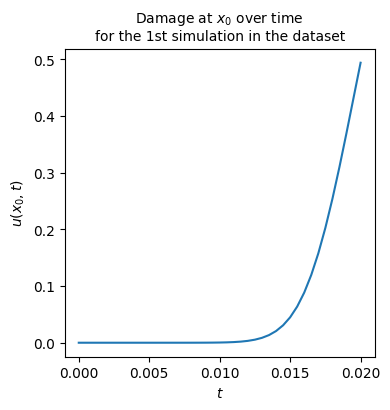

In [ ]:
# Define nt
nt = len(u0)

# Define T, that is the (number of time steps) * (dt).
T = (nt-1)*5e-4

# Define the x-axis
time_grid = np.linspace(0, T, nt)

# Do the plot and custom the texts
plt.figure(figsize = (4, 4))
plt.plot(time_grid, damage_atx0.cpu().numpy())              # Bring back damage as an array
plt.title("Damage at $x_0$ over time\nfor the 1st simulation in the dataset", fontsize = 10)
plt.xlabel("$t$")
plt.ylabel("$u(x_0,t)$")
None

In [ ]:
# Measurements available (corresponding to "evaluate(u)" for some unknown u!)
gdown.download(id = "16htWP91l5tpgK3ZYqjK-GHvVpW7lr2a5", quiet = False, output = "damage_measurements.npy")
clc()

# Information related to the damage analyzed from the sensor (i.e. solution u_sensor(x_0, t))
damage_measurements = np.load("damage_measurements.npy")

# Define the shape
damage_measurements.shape

(41, 1)

## 1) Apply the minimization on POD-NN

The code already had available results of the measurements of the sensor. We must determine the values of $\mu$ such that we have:
$$
\min_{D,R,\delta}\ \frac{1}{M}\sum_{j=1}^{M}
\left| m_j - \hat{u}_j(x_0) \right|^2
$$

As always, I did the process with both POD-NN and DL-ROM. The process is identical. The difference is only on the result and on the application of the neural network. In both cases, we used for comparison, obviously, the solution $\tilde{u}_h$.

### **Algorithm of both POD-NN and DL-ROM:**
1. To apply the minimization, I developed two different techniques. The algorithm that I commented has been taught this semester from the course of "Advanced Dynamics", which relies on choosing certain random values as starting point. It gives quite good solutions, but the effective approach that I decided to apply, which is not highly different from the commented one, has a greater accuracy. The algorithm is based on defining the objective function which we aim to minimize and the inputs of these functions. Consequently, we impose a bound and apply the optimization process in order to determine the optimal values of $\mu$.

2. Now that we have the $\mu$ values which minimize the system the difference, we simply print them.

3. Finally, we simply plot the results one over the other and see the similarity.

### Results
From the plots, we can see that both POD-NN and DL-ROM give us accurate representations and we may be considered satisfied. Until now, applying POD-NN instead of DL-ROM didn't lead us to significant problems although the number of modes is significantly high.

### 1. Apply the optimization

In [ ]:
# damage_at_x0 is the effective damage occured. damage_measurement is what has been measured from us. Now, we can proceed. We need to compare damage_at_x0 wrt uROM.
# How do we consider uROM at x0? It is all done in the objective function and on the optimization
# 1. We write uROM in function of the point of x_0.
# 2. We write uROM and damage_measurement in function of D, r and delta on the formula
# 3. We set the parameters such that the difference is minimized for the sum, where the sum is up to 41

In [ ]:
# Import the library
from scipy.optimize import minimize, differential_evolution
model.to(dv)
Vn = dv.tensor(Vn)
evaluate.to(dv)
# Define the function
def objective(params, nt, model, Vn, evaluate, damage_measurements):
    mu_obj = torch.zeros((nt, p + 1)).to(dv.device)                              # Define the matrix of mu
    mu_obj[:, :p] = torch.tensor(params, dtype=torch.float32).to(dv.device)      # Fill the mu matrix
    mu_obj[:, p] = torch.linspace(0, T, nt).to(dv.device)                        # Fill the mu matrix
    uROM_full = model(mu_obj) @ Vn.T                                             # Define the uROM solution in function of the new mu; this new mu fits well for the determination of the minimum
    uROM_obj = evaluate(uROM_full).detach().cpu().numpy().flatten()              # evaluate uROM on the points of interest
    return np.mean((damage_measurements.flatten() - uROM_obj)**2)                # The formula is a simple mean. Therefore, by defining mean, we define also the presence of 1/nt

# Apply the optimization
bounds = [(0, 1), (0, 1), (0, 1)]
res = differential_evolution(objective, bounds=bounds, args=(nt, model, Vn, evaluate, damage_measurements))

# Now that we have the mu values, define the values of D, r and delta
mu_opt = res.x                                                                   # Needed to exploit the info from the res, that is the optimizer.
D_est = 10**mu_opt[0]
r_est = 10**(mu_opt[1] + 2)
delta_est = mu_opt[2] + 1

# Print the results
print("The parameters are:")
print(f"1. D = {D_est:.2f}")
print(f"2. r = {r_est:.2f}")
print(f"3. δ  = {delta_est:.2f}")

The parameters are:
1. D = 1.22
2. r = 999.77
3. δ  = 1.85


### 2. Define $\mu_{min}$ vector

In [ ]:
# With the algorithm, we found the values of mu such that we minimize the objective function. We define mu_min
mu_opt = res.x          # Vector constituted of the 3 parameters optimized

print("The parameters mu are:")
print(f"1. mu1 = {mu_opt[0]:.2f}")
print(f"2. mu2 = {mu_opt[1]:.2f}")
print(f"3. mu3  = {mu_opt[2]:.2f}")

The parameters mu are:
1. mu1 = 0.09
2. mu2 = 1.00
3. mu3  = 0.85


### 3. Define the plot

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4110/2885073115.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(time_grid, damage_est_atx0, 'b-', linewidth=2, label="ROM associated to $\mu_{opt}$")                   # Plot 2 => What my solution found


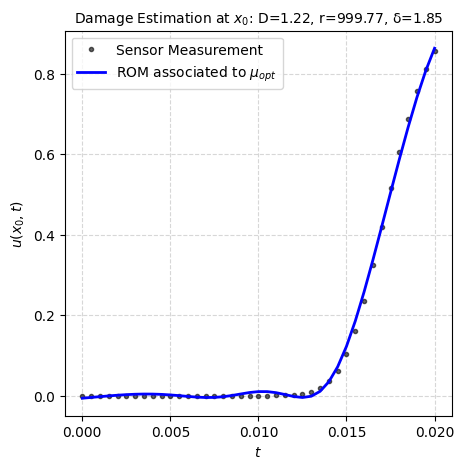

In [ ]:
# Define the mu that we found => analyzing the evolution of mu along each time step
mu_final = torch.zeros((nt, p + 1)).to(dv.device)
mu_final[:, :p] = torch.tensor(mu_opt, dtype=torch.float32).to(dv.device)
mu_final[:, p] = torch.linspace(0, T, nt).to(dv.device)

# Define the value of uROM associated to the mu_opt we found
uROM_final = model(mu_final) @ Vn.T
damage_est_atx0 = evaluate(uROM_final).detach().cpu().numpy()

# Create the plot
plt.figure(figsize = (5, 5))
plt.plot(time_grid, damage_measurements, 'ko', markersize=3, label="Sensor Measurement", alpha=0.6)    # Plot 1 => What the sensor detects
plt.plot(time_grid, damage_est_atx0, 'b-', linewidth=2, label="ROM associated to $\mu_{opt}$")                   # Plot 2 => What my solution found

# Custom the plot
plt.title(f"Damage Estimation at $x_0$: D={D_est:.2f}, r={r_est:.2f}, δ={delta_est:.2f}", fontsize = 10)
plt.xlabel("$t$")
plt.ylabel("$u(x_0,t)$")
plt.xticks(torch.linspace(0, T, 5).numpy())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##2) Apply the minimization with DL-ROMs

### 1. Apply the optimization


In [ ]:
# Import the library
from scipy.optimize import minimize, differential_evolution
import torch
import numpy as np

def objectiveDLROM(params, nt, p, T, evaluate, decoder, phi_dlrom, damage_measurements):
    mu_obj_dlrom = torch.zeros((nt, p + 1)).to(dv.device)                              # Define the matrix of mu
    mu_obj_dlrom[:, :p] = torch.tensor(params, dtype=torch.float32).to(dv.device)      # Fill the mu matrix
    mu_obj_dlrom[:, p] = torch.linspace(0, T, nt).to(dv.device)                        # Fill the mu matrix
    z_pred = phi_dlrom(mu_obj_dlrom)                                                   # FIND uROM
    uROM_dlrom_full = decoder(z_pred)                                                  # FIND uROM
    uROM_obj_dlrom = evaluate(uROM_dlrom_full).detach().cpu().numpy().flatten()        # Evaluate uROM on the points of interest
    return np.mean((damage_measurements.flatten() - uROM_obj_dlrom)**2)

# Apply the optimization
bounds = [(0, 1), (0, 1), (0, 1)]
res_dlrom = differential_evolution(objectiveDLROM, bounds=bounds, args=(nt, p, T, evaluate, decoder, phi_dlrom, damage_measurements), tol=1e-4)

# Now that we have the mu values, define the values of D, r and delta
mu_opt_dlrom = res_dlrom.x                                                             # Needed to exploit the info from the res, that is the optimizer.
D_est_dlrom = 10**mu_opt_dlrom[0]
r_est_dlrom = 10**(mu_opt_dlrom[1] + 2)
delta_est_dlrom = mu_opt_dlrom[2] + 1

# Print the results
print("The parameters are:")
print(f"1. D = {D_est_dlrom:.2f}")
print(f"2. r = {r_est_dlrom:.2f}")
print(f"3. δ  = {delta_est_dlrom:.2f}")

The parameters are:
1. D = 1.10
2. r = 1000.00
3. δ  = 1.77


### 2. Define $\mu_{min}$ vector

In [ ]:
# With the algorithm, we found the values of mu such that we minimize the objective function. We define mu_min
mu_opt_dlrom = res_dlrom.x          # Vector constituted of the 3 parameters optimized

print("The parameters mu are:")
print(f"1. mu1 = {mu_opt_dlrom[0]:.2f}")
print(f"2. mu2 = {mu_opt_dlrom[1]:.2f}")
print(f"3. mu3  = {mu_opt_dlrom[2]:.2f}")

The parameters mu are:
1. mu1 = 0.04
2. mu2 = 1.00
3. mu3  = 0.77


### 3. Define the plot

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4110/4292305825.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(time_grid, damage_est_atx0_dlrom, 'b-', linewidth=2, label = "ROM associated to $\mu_{opt}$")              # Plot 2 => What my solution found


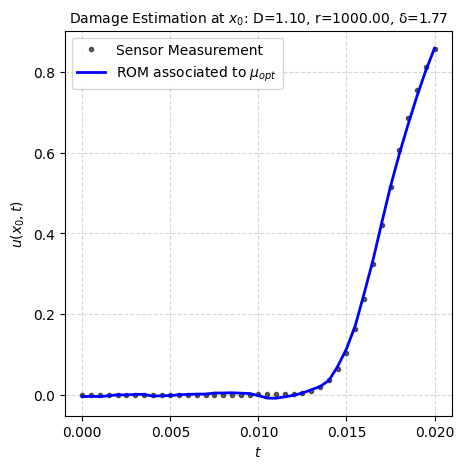

In [ ]:
# Define the mu that we found => analyzing the evolution of mu along each time step
mu_final_dlrom = torch.zeros((nt, p + 1)).to(dv.device)
mu_final_dlrom[:, :p] = torch.tensor(mu_opt_dlrom, dtype=torch.float32).to(dv.device)
mu_final_dlrom[:, p] = torch.linspace(0, T, nt).to(dv.device)

# Define the value of uROM associated to the mu_opt we found
z_for_plot = phi_dlrom(mu_final_dlrom)                                                                                    # FIND uROM
uROM_dlrom_for_plot = decoder(z_for_plot)                                                                           # FIND uROM
damage_est_atx0_dlrom = evaluate(uROM_dlrom_for_plot).detach().cpu().numpy()

# Create the plot
plt.figure(figsize = (5, 5))
plt.plot(time_grid, damage_measurements, 'ko', markersize=3, label = "Sensor Measurement", alpha=0.6)               # Plot 1 => What the sensor detects
plt.plot(time_grid, damage_est_atx0_dlrom, 'b-', linewidth=2, label = "ROM associated to $\mu_{opt}$")              # Plot 2 => What my solution found
plt.xticks(torch.linspace(0, T, 5).numpy())

# Custom the plot
plt.title(f"Damage Estimation at $x_0$: D={D_est_dlrom:.2f}, r={r_est_dlrom:.2f}, δ={delta_est_dlrom:.2f}", fontsize = 10)
plt.xlabel("$t$")
plt.ylabel("$u(x_0,t)$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Other technique based on guessing value (less accurate)

In [ ]:
#################################################### APPROACH WITH GUESSING VALUE FOR BOTH POD-NN AND DL-ROM ##################################################################################
# from scipy.optimize import minimize
# import torch
# import numpy as np


# def objectiveDLROM(params, nt, p, T, evaluate, decoder, phi_dlrom, damage_measurements):
# mu_obj_dlrom = torch.zeros((nt, p + 1)).to(dv.device)                              # Define the matrix of mu
# mu_obj_dlrom[:, :p] = torch.tensor(params, dtype=torch.float32).to(dv.device)      # Fill the mu matrix
# mu_obj_dlrom[:, p] = torch.linspace(0, T, nt).to(dv.device)                        # Fill the mu matrix
# z_pred = phi_dlrom(mu_obj_dlrom)                                                   # FIND uROM
# uROM_dlrom_full = decoder(z_pred)                                                  # FIND uROM
# uROM_obj_dlrom = evaluate(uROM_dlrom_full).detach().cpu().numpy().flatten()        # Evaluate uROM on the points of interest
# return np.mean((damage_measurements.flatten() - uROM_obj_dlrom)**2)


# # Apply the optimization

# res_dlrom = minimize(objectiveDLROM, x0=[0.5, 0.5, 0.5], args=(nt, p, T, evaluate, decoder, phi_dlrom, damage_measurements), bounds=[(0, 1), (0, 1), (0, 1)], options={'eps': 1e-3})


# # Now that we have the mu values, define the values of D, r and delta

# mu_opt_dlrom = res_dlrom.x                                                        # Needed to exploit the info from the res, that is the optimizer.
# D_est_dlrom = 10mu_opt_dlrom[0]
# r_est_dlrom = 10(mu_opt_dlrom[1] + 2)
# delta_est_dlrom = mu_opt_dlrom[2] + 1


# # Print the results

# print("The parameters are:")
# print(f"1. D = {D_est_dlrom:.2f}")
# print(f"2. r = {r_est_dlrom:.2f}")
# print(f"3. δ  = {delta_est_dlrom:.2f}")
################################################################# POD-NN ################################################################
# # Import the library
# from scipy.optimize import minimize
# # params = [D, r, delta]
# model.to(dv)
# Vn = dv.tensor(Vn)
# evaluate.to(dv)
# # Define the function
# def objective(params, nt, model, Vn, evaluate, damage_measurements):
#     mu_obj = torch.zeros((nt, p + 1)).to(dv.device)                              # Define the matrix of mu
#     mu_obj[:, :p] = torch.tensor(params, dtype=torch.float32).to(dv.device)      # Fill the mu matrix
#     mu_obj[:, p] = torch.linspace(0, T, nt).to(dv.device)                        # Fill the mu matrix
#     uROM_full = model(mu_obj) @ Vn.T                                             # Define the uROM solution in function of the new mu; this new mu fits well for the determination of the minimum
#     uROM_obj = evaluate(uROM_full).detach().cpu().numpy().flatten()              # evaluate uROM on the points of interest
#     return np.mean((damage_measurements.flatten() - uROM_obj)**2)                # The formula is a simple mean. Therefore, by defining mean, we define also the presence of 1/nt

# # Apply the optimization
# res = minimize(objective, x0=[0.5, 0.5, 0.5], args=(nt, model, Vn, evaluate, damage_measurements), bounds=[(0, 1), (0, 1), (0, 1)], options={'eps': 1e-3})

# # Now that we have the mu values, define the values of D, r and delta
# mu_opt = res.x                                                                   # Needed to exploit the info from the res, that is the optimizer.
# D_est = 10**mu_opt[0]
# r_est = 10**(mu_opt[1] + 2)
# delta_est = mu_opt[2] + 1

# # Print the results
# print("The parameters are:")
# print(f"1. D = {D_est:.2f}")
# print(f"2. r = {r_est:.2f}")
# print(f"3. δ  = {delta_est:.2f}")

## Predictions (based on testing the algorithm and not finding an adeguate result)


In order to know which is the behavior our solution $u$ at the instant $t^* = 2T = 0.04$ at point $x^* = (3.5, 2)$, we must rely to either DMD or SINDy.

### **DMD:**
This model relies on a linear approach, that can be better defined as:
$$\frac{da}{dt} = La$$
with $L \in \mathbb{R}^{N \times N} $.
This approach has not been, as I tried, very efficient. The results were not so promising. This was due to the fact that such linear approach is not that accurate to manage properly the analysis of such an unstable quasi-linear system with such a unstable behavior. Difficult to predict with DMD.

### **SINDy with POD-NN**
An issue occured with SINDy. Indeed, SINDy is expected to make predictions directly from the *latent space*. However, the main problem is that SINDy has a very big space, leading us to determine 50 equations which then need to be integrated. I tried to implement different techniques in order to allow the system to give me reliable results, but with no success, such as:

1. Reducing the number of modes from Utrain in the first point: It actually helped to decrease the amount of computations, but the error increased significantly and having few representative modes and neglecting many modes which had a quite significant high energy was not a safe solution. It implied the loss of important information.
2. I tried to increase significantly the value of the threshold and alpha, but since the threshold had to be increased too much in order to obtain coefficients which where not big enough.
3. I tried to mix the approach 1 with approach 2, but it did not help. As a result, I have been able to run the code because the coefficients were not that big, but the results were absolutely not compliant and did not make any sense. In addition, the $L^2$ error increased significantly.

### **SINDy with DL-ROM**
SINDy with DL-ROM was more compliant. I have been able to obtain results in an easier approach and this made sense. Indeed, as the dimension space is very small, we expect much less equations with respect to POD-NN. If previously we had $50$ equations, here do not even reach $10$. Therefore, the number of equations to be integrated are much less.

### 1) DMD with POD-NN

### 1. Develop the utrain

The process has been the following:

1. I defined a function which allows to fastly obtain the value of $\tilde{u}_h$. Then, I applied such function in order to define utrain. At the end, I splitted utrain in 2 parts: unow and unext (they differ only of one column).
2. I applied the SVD as always
3. I applied the DMD, obtaining as output the behavior of the system at each time instant, including also the one at $t = 2T$.
4. I analyzed, by applying the variables given by the professor, the damage at the point of my interest. The idea is identical to what is on the code that professor shows on point 3.

In [ ]:
# Do we need to use SINDy or DMD? SINdy guarantees the solution of the problem, while DMD is a more simplified approach which comes in our help. Let's use DMD
# Define the function for the POD-NN solver

In [ ]:
# Define the function for the POD-NN solver
def PODNNsolver(mu_new, time_grid):
  mu_evol = dv.zeros(len(time_grid), p+1)
  mu_evol[:, p] = dv.tensor(time_grid)
  mu_evol[:, :p] = dv.tensor(mu_new)
  return (model(mu_evol) @ Vn.T).cpu().numpy()

In [ ]:
# Define the utrain
utrain = PODNNsolver(mu_opt, time_grid = np.linspace(0, T, nt))    # The training must be done wrt the interval that we know. We can't use 2*T and/or 2*nt here because here we have no prediction analysis.
utrain.shape
print(f"The shape of utrain is compliant, as we have number of time steps = {utrain.shape[0]} and number of DOFs = {utrain.shape[1]}. This respects the rules")

The shape of utrain is compliant, as we have number of time steps = 41 and number of DOFs = 6636. This respects the rules


In [ ]:
# Define unow and unext
unow = utrain.T[:, :-1] # all except the last one
unext = utrain.T[:, 1:] # all except the first

### 2. Apply the SVD

In [ ]:
from scipy.linalg import svd, eig

# Apply the SVD by using n = 50 (defined earlier)
U, sigma, Vt = svd(unow, full_matrices = False)
U, sigma, Vt = U[:, :n], sigma[:n], Vt[:n, :]

# Define S (as always)
S = U.T @ unext @ Vt.T @ np.diag(1.0/sigma)

# Define the eigenvalues and eigenvectors
eigenvalues, rotated_eigenvectors = eig(S)
eigenvectors = U @ rotated_eigenvectors
eigenvalues = eigenvalues

In [ ]:
S.shape # (i.e. (nt-1) x (nt-1))

(40, 40)

### 3. Apply the DMD

In [ ]:
# Define the DMD evolution => We define a function which solves the linear system and returns a value
def DMDevolve(u_initial, steps):
  c = np.linalg.lstsq(eigenvectors, u_initial)[0]
  return np.stack([np.real(eigenvectors @ (eigenvalues**k*c)) for k in range(steps)], axis = 1)

In [ ]:
# Apply the function by considering the last time step that is known (i.e. solve the linear system and return a value) to the present value
uDMD = DMDevolve(utrain[-1], nt)
uDMD.shape

(6636, 41)

In [ ]:
# Start with the prediction => upred must consider all the DOFs and the time instants are doubled (why??)
upred = np.zeros(( 2 * nt, nh))
upred[:nt] = utrain
upred[nt:] = uDMD.T
print(f"Now that our upred has shape {upred.shape}, we can analyze what occurs at the instant 2 * T, that occurs at the 82th step!")

Now that our upred has shape (82, 6636), we can analyze what occurs at the instant 2 * T, that occurs at the 82th step!


In [ ]:
utrain.shape, uDMD.shape, upred.shape

((41, 6636), (6636, 41), (82, 6636))

### 4. Analyze the point and time of interest

In [ ]:
# Define the instant of interest
u_instant_of_interest = upred[81,:]

In [ ]:
u0.shape, upred.shape, u_instant_of_interest.shape

(torch.Size([41, 6636]), (82, 6636), (6636,))

In [ ]:
# Library added with AI in order to avoid error due tensors
from dlroms.cores import GPU
dv = GPU

# Evaluate the point of interest
x_star = np.array([[3.5, 2]])                                                   # This is representing the point of interest

# Compute the evaluation on the mesh considering all dofs and transform such evaluation in a tensor
evaluate_star = Evaluate(mesh, Vh, x_star)
evaluate_star.to(dv)

# Pass upred to a sensor
upred = dv.tensor(upred)

# Usage example; example for the very first u of the fom
u_star = upred
damage_at_x_star = evaluate_star(u_star)

# Define the shape
damage_at_x_star.shape

torch.Size([82, 1])

In [ ]:
print(f"The shape of the damage at the point of interest makes sense, as it is {damage_at_x_star.shape}, that is literally identical to {damage_atx0.shape} but with half of the intervals.")

The shape of the damage at the point of interest makes sense, as it is torch.Size([82, 1]), that is literally identical to torch.Size([41, 1]) but with half of the intervals.


In [ ]:
print(f"The value of u when we are at t* = 2*T and at position {x_star} is:")
print(f"{damage_at_x_star[81]}")

The value of u when we are at t* = 2*T and at position [[3.5 2. ]] is:
tensor([0.8322], device='cuda:0')


### 2) SINDy with DL-ROMs

### **4. Sensor analysis and extrapolation monitoring**

To evaluate what occurs at the point of my interest, the best solution is to apply SINDy with the DL-ROM. The process is not that different , I performed a sensor analysis in a specific point of interest $x^*$. This approach allows us to monitor the evolution of the damage $u(x^*, t)$ over time, comparing the predicted behavior with the expected physical propagation defined by the FKPP equation. The steps have been the following:

1. First, I defined the function for the DLROMsolver which is expected to return, as we did during our lectures, the latent solution of our system. Consequently, I defined the latent solution, from which I have been able to represent the value of $zstate$ and $zdot£, which are simply representing the behavior of the state in the present and it's derivative.

2. Furthermore, I applied SINDy model. Here, I spent most of the time of the project in order to determine which could be a good implementation of the system. As output, we are expected to obtain four equations, which is the number of dimension. This is the reason for which I decided to put the number of dimensions smaller than expected, altough I am expected to have less accuracy. I played with the threshold and the value of alpha in order to find a good fit.

3. At the end, I did the evaluation for the point of interest and determined the value that I am expected to obtain in that point for the time of interest. THen, I represented the results through both the animation and the plot.

## **Results:**
The result has been continuously repeated, changed, applied with many different techniques, where some were more coherent with the physics of the system and others were less coherent. As the data is associated to an unstable behavior, predicting the behavior is not very easy. In order to obtain better results, the only thing which can done is to play with the latent dimension, threshold, alpha, libraries and the neural networks. I decided to play - not randomly - with all of them continuously, but this is one of the results, i.e., the last, that I have been able to obtain.

## **Final plot:**
The final plot shows a behavior which goes against the possible physical behavior. The conclusion is that obtaining a prediction with SINDy and/or DMD for this specific system requires a fit which might require a lot of time in order to have a fast and reliable result. I tried to change any type of value (latent dimension, threshold, library, functions, activation functions, neural networks, etc.) but the system does not predict something which can physically make sense. In a trial, I have been able to obtain a plot which was monotically increasing, until a certain value, which made sense in my opinion, but implied an error of the neural network which was too high. The plot obtained shows that the system is increasing its its damage, and until the increasing part made sense. Then, the system decreases an exceeds the boundary values, losing signifincantly the physical reliability.

In [ ]:
# Import the libraries
from IPython.display import clear_output as clc
try:
  from pysindy import SINDy, CustomLibrary, STLSQ
except:
  !pip install git+https://github.com/dynamicslab/pysindy.git
  clc()
  from pysindy import SINDy, CustomLibrary, STLSQ

### 1. Define the input for SINDy

In [ ]:
# Define the function for the POD-NN solver
def DLROMsolver(mu_new_dlrom, time_grid):
  mu_evol_dlrom = dv.zeros(len(time_grid), p+1)                                 # Create a mu matrix where: column = a specific parameter; row = a specific time instant
  mu_evol_dlrom[:, p] = dv.tensor(time_grid)                                    # Fill the last column only with all the time instants
  mu_evol_dlrom[:, :p] = dv.tensor(mu_new_dlrom)                                # Fill the other 3 columns with the values of mu
  return (phi_dlrom(mu_evol_dlrom)).detach().cpu().numpy()             # Apply the calculation with the decoder

In [ ]:
# Define the utrain
ztrain_dlrom = DLROMsolver(mu_opt_dlrom, time_grid = np.linspace(0, T, nt))     # The training must be done wrt the interval that we know. We can't use 2*T and/or 2*nt here because here we have no prediction analysis.
ztrain_dlrom.shape

(41, 4)

In [ ]:
z_state_dlrom = ztrain_dlrom[1:-1]
z_dot_dlrom = (ztrain_dlrom[2:] - ztrain_dlrom[:-2]) / (2.0 * dt)

### 2. Apply the SINDy

In [ ]:
# Import the libraries
from pysindy.feature_library import PolynomialLibrary
from pysindy.optimizers import STLSQ

# Define the number of dimensions
dim = latent
dt = 5e-4

fs_working = [
    lambda z: z,
    # lambda z,w: z*w,
    # lambda z: z*(1-z),
    # lambda z: 1 / (1 + np.exp(-z))
    lambda z: np.tanh(z)
]

# Define the library
custom_library = CustomLibrary(library_functions=fs_working)
# poly_library = PolynomialLibrary(degree=2, include_interaction=True)                              # I avoid the calculation of mixed products
# library = poly_library + custom_library

# Define the optimization
optimizer = STLSQ(threshold=4, alpha=4.5)

# Define the model
sindy_model = SINDy(feature_library=custom_library, optimizer=optimizer)

# Do the fitting
sindy_model.fit(z_state_dlrom, x_dot = z_dot_dlrom, t=dt, feature_names=["z%d" % i for i in range(1, dim+1)])

# Print the results
print("Identified Equations for the LATENT DYNAMICS (DL-ROM):")
sindy_model.print()

Identified Equations for the LATENT DYNAMICS (DL-ROM):
(z1)' = -33.553 f0(z1) +  115.816 f0(z2) + -88.634 f0(z3) + -51.098 f0(z4) + -702.354 f1(z2) + -327.791 f1(z3) +  892.651 f1(z4)
(z2)' = -165.451 f0(z1) + -33.691 f0(z2) +  380.872 f0(z3) +  239.406 f0(z4) + -26.353 f1(z1) + -1604.398 f1(z2) +  4.119 f1(z3) +  1643.788 f1(z4)
(z3)' = -41.319 f0(z1) +  115.058 f0(z3) +  233.385 f0(z4) + -244.023 f1(z1) + -470.279 f1(z2)
(z4)' =  33.552 f0(z1) +  196.925 f0(z2) + -790.425 f0(z3) +  16.663 f0(z4) +  3539.977 f1(z2) +  1488.418 f1(z3) + -4424.681 f1(z4)


### 3. Finalize the SINDy

In [ ]:
mu_opt_dlrom.shape

(3,)

In [ ]:
# Define the time grid for the extrapolation
t_extrap = np.linspace(0, T, nt)

# The last known state acts as initial condition: z_train_sindy[-1]; we use the fitted SINDy model to simulate the coefficients' evolution.
try:
    c_extrap_dlrom = sindy_model.simulate(z_state_dlrom[-1], t=t_extrap)
except ValueError:
    print("Error: The simulation is still diverging. Try increasing the STLSQ threshold.")
    c_extrap_dlrom = np.tile(z_state_dlrom[-1], (nt, 1)) # Fallback to constant if it fails

# Reconstruct the predicted solution in the full space
uSINDy_extrap_dlrom = decoder(dv.tensor(c_extrap_dlrom)).detach().cpu().numpy().T

### Evaluate the point of interest at the instant of interest

In [ ]:
# Assemble the complete prediction trajectory => Developing the prediction
upred_sindy_dlrom = np.zeros((2 * nt, nh))
upred_sindy_dlrom[:nt] = utrain
upred_sindy_dlrom[nt:] = uSINDy_extrap_dlrom.T

print(f"Total snapshots: {upred_sindy_dlrom.shape}")
# Evaluate the damage at x* at the instant t*

Total snapshots: (82, 6636)


In [ ]:
# Convert upred_sindy to a tensor
upred_sindy_dlrom = dv.tensor(upred_sindy_dlrom)

# Evaluate the damage at x_star using "evaluate"
damage_at_x_star_sindy_dlrom = evaluate_star(upred_sindy_dlrom)

# The value at t* = 0.04 corresponds to the last snapshot index
damage_final_dlrom = damage_at_x_star_sindy_dlrom[-1]

print(f"The predicted damage at x* = {x_star} and t* = 0.04 is: {damage_final_dlrom.item():.4f}")

The predicted damage at x* = [[3.5 2. ]] and t* = 0.04 is: 0.2105


In [ ]:
damage_at_x_star_sindy_dlrom.shape

torch.Size([82, 1])

### Do the plot

/usr/local/lib/python3.12/dist-packages/dlroms/cores.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return ttensor(arrays[0], dtype = self.dtype, device = self.device)


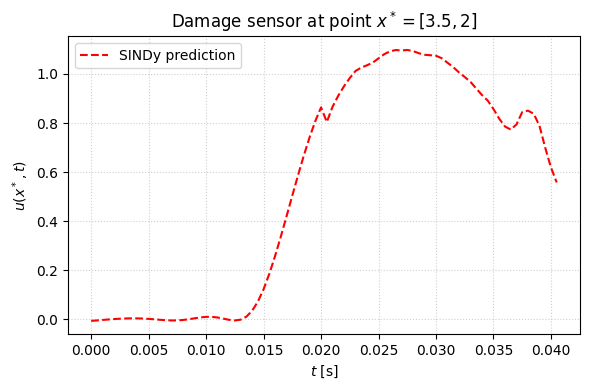

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the prediction to a tensor
upred_sindy_dv = dv.tensor(upred_sindy_dlrom)
# Evaluate the damage at the x_star point
damage_at_x_star = evaluate(upred_sindy_dv)

# Convert to numpy for plotting
damage_np = damage_at_x_star.detach().cpu().numpy().flatten()

# Create the time vector
nt_total = len(damage_np)
dt = 5e-4
time_grid = np.linspace(0, (nt_total - 1) * dt, nt_total)

# Generate the plot
plt.figure(figsize=(6, 4))
plt.plot(time_grid, damage_np, label='SINDy prediction', color='red', linestyle='--')

plt.title(f"Damage sensor at point $x^* = [3.5, 2]$", fontsize=12)
plt.xlabel("$t$ [s]", fontsize=10)
plt.ylabel("$u(x^*, t)$", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

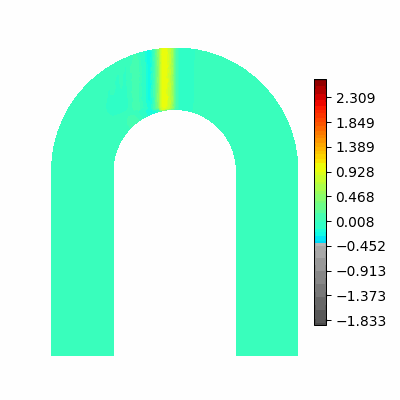

In [ ]:
fe.animate(upred_sindy_dlrom, Vh, colorbar = True, cmap = gray_jet)

### 1) SINDy with POD-NN

For the POD-NN, the process has been identical to the one applied for DL-ROM. Obviously, the unique difference is that the integration is expected to **not work** due to the fact that the number of modes is too high. Altough this part does not properly run, it has been put in order to highlight how I approached to the problem as something else which was not requested. Indeed, for the answer to the fourth point of the problem, it is possible to rely only on DL-ROM + SINDy. All the steps realized with POD-NN are something added only.

### Do the training

In [ ]:
# Import the libraries
from pysindy.feature_library import PolynomialLibrary
from pysindy.optimizers import STLSQ

# Define the initial condition of the system for the prediction of future
u_initial_condition = utrain[-1]

# Define the values
dim = n
dt = 5e-4

# Project the utrain data on Vn; we have "ctrain", that is the train version of c
utrain = dv.tensor(utrain)
ctrain = (utrain @ Vn).detach().cpu().numpy()

#3. Library Definition (Crucial!) Since Fisher-KPP has a term u(1-u) = u - u^2, we use PolynomialLibrary with degree=2 (includes constants, linear and quadratic terms)
library = PolynomialLibrary(degree = 2, include_interaction = False)

# Configuration of the model => # STLSQ (Sequentially Thresholded Least Squares) promotes sparsity
optimizer = STLSQ(threshold=1, alpha = 4.0)               # alpha is needed to increase the stability (it reduced the risk of instability as we increase it)
# alpha => robustness
# threshold => sparsity

# Define the SINDy model
sindy_model = SINDy(feature_library=library, optimizer=optimizer)

# Fit the model on POD's coefficients; SINDy will calculate internally the derivatives
sindy_model.fit(ctrain, t=dt, feature_names = ["z%d" % i for i in range(1, dim+1)])

# Print the results
print("Identified Equations (Stabilized):")
sindy_model.print()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (1) and eliminated all coefficients
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (1) and eliminated all coefficients
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (1) and eliminated all coefficients
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (1) and eliminated all coefficients
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (1) and eliminated all 

Identified Equations (Stabilized):
(z1)' = -6.179 1 +  32.645 z1 +  79.370 z2 +  92.485 z3 + -8.543 z4 + -42.996 z5 + -32.715 z6 + -9.507 z7 +  6.506 z8 + -23.554 z9 +  16.911 z10 + -18.192 z12 + -2.565 z15 + -1.638 z16 +  35.516 z17 +  21.701 z21 +  12.033 z22 + -0.730 z2^2 + -3.934 z3^2 + -3.650 z4^2 + -10.115 z5^2 + -24.767 z6^2 + -8.217 z7^2 + -27.599 z8^2 +  13.421 z9^2 + -1.430 z10^2 +  54.550 z11^2 +  8.896 z12^2 + -60.828 z13^2 +  8.476 z14^2 +  52.513 z15^2 +  33.820 z16^2 + -74.794 z19^2 + -41.855 z21^2 +  0.860 z24^2 + -21.098 z27^2
(z2)' = -10.520 1 +  31.765 z1 +  7.137 z2 +  38.842 z3 + -59.003 z5 + -13.216 z6 + -78.899 z7 +  20.217 z8 + -19.509 z10 + -42.726 z11 +  15.408 z12 +  17.515 z13 + -3.790 z14 + -8.278 z15 + -4.128 z16 + -10.492 z19 + -8.094 z23 +  1.214 z32 +  2.559 z1^2 + -4.158 z2^2 + -1.076 z3^2 + -5.828 z4^2 +  5.486 z5^2 +  5.675 z7^2 +  4.729 z8^2 + -5.006 z9^2 +  6.529 z11^2 +  17.761 z12^2 + -11.047 z13^2 + -14.038 z14^2 +  19.125 z15^2 + -1.655 z16^2 +

In [ ]:
coef = sindy_model.coefficients()

print(coef.shape)
print("max coef =" , np.abs(coef).max())
print("mean coef=", np.abs(coef).mean())

(50, 101)
max coef = 862.4974365234375
mean coef= 8.402138716979044


In [ ]:
print(f"The shape of ctrain is: {ctrain.shape}, where nt = 41 and n = 50.")

The shape of ctrain is: (41, 50), where nt = 41 and n = 50.


### Finalize the SINDy

In [ ]:
# Define the time grid for the extrapolation
t_extrap = np.linspace(0, T, nt)

# Check if the SINDy model is already saved, if so, load it
import pickle
sindy_model_path = "sindy_model_dlrom.pkl"

if os.path.exists(sindy_model_path):
    print(f"Loading pre-trained SINDy model from {sindy_model_path}")
    with open(sindy_model_path, "rb") as f:
        sindy_model = pickle.load(f)
else:
    print("Fitting SINDy model...")
    # The last known state acts as initial condition: ctrain[-1]; we use the fitted SINDy model to simulate the coefficients' evolution.
    try:
        c_extrap = sindy_model.simulate(ctrain[-1], t=t_extrap)
    except ValueError:
        print("Error: The simulation is still diverging. Try increasing the STLSQ threshold.")
        c_extrap = np.tile(ctrain[-1], (nt, 1)) # Fallback to constant if it fails

# If the model was loaded, c_extrap needs to be generated based on the loaded model
if 'c_extrap' not in locals(): # This checks if c_extrap was defined in the 'else' block
    try:
        c_extrap = sindy_model.simulate(ctrain[-1], t=t_extrap)
    except ValueError:
        print("Error: The simulation is still diverging after loading the model. Try increasing the STLSQ threshold.")
        c_extrap = np.tile(ctrain[-1], (nt, 1)) # Fallback to constant if it fails

# Reconstruct the predicted solution in the full space
uSINDy_extrap = c_extrap @ Vn.detach().cpu().numpy().T

# Define the time grid for the extrapolation
t_extrap = np.linspace(0, T, nt)

# # The last known state acts as initial condition: ctrain[-1]; we use the fitted SINDy model to simulate the coefficients' evolution.
# try:I
#     c_extrap = sindy_model.simulate(ctrain[-1], t=t_extrap)
# except ValueError:
#     print("Error: The simulation is still diverging. Try increasing the STLSQ threshold.")
#     c_extrap = np.tile(ctrain[-1], (nt, 1)) # Fallback to constant if it fails

# # Reconstruct the predicted solution in the full space
# uSINDy_extrap = c_extrap @ Vn.detach().cpu().numpy().T

Fitting SINDy model...


KeyboardInterrupt: 

In [ ]:
# Assemble the complete prediction trajectory => Developing the prediction
upred_sindy = np.zeros((2 * nt, nh))
upred_sindy[:nt] = utrain.cpu().numpy()
upred_sindy[nt:] = uSINDy_extrap

print(f"The SINDy prediction is ready. Total snapshots: {upred_sindy.shape}")

In [ ]:
# Evaluate the damage at x* at the instant t*

# Convert upred_sindy to a tensor
upred_sindy_dv = dv.tensor(upred_sindy)

# Evaluate the damage at x_star using "evaluate"
damage_at_x_star_sindy = evaluate_star(upred_sindy_dv)

# The value at t* = 0.04 corresponds to the last snapshot index
damage_final = damage_at_x_star_sindy[-1]

print(f"The predicted damage at x* = {x_star} and t* = 0.04 is: {damage_final.item():.4f}")